# Linear vs Nonlinear Approximation of Images

Compression and approximation are about representing a signal with fewer degrees of freedom while retaining perceptual quality.
A central insight in harmonic analysis is that **where** you spend coefficients matters as much as **how many** you keep.

We compare:
$$
\text{Linear approximation: keep a fixed low-frequency block in Fourier space}
$$
against
$$
\text{Nonlinear approximation: keep largest-magnitude wavelet coefficients.}
$$

The notebook shows how sparsity-adapted representations can preserve edges and geometry better at equal budget.

A shared coefficient budget and matched display scale make the visual comparison a controlled numerical experiment rather than a qualitative juxtaposition.


## Environment

We use NumPy/Matplotlib and implement a compact orthogonal Haar transform directly in Python.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

plt.rcParams["figure.dpi"] = 120
rng = np.random.default_rng(0)


## Test image

We build a synthetic image with smooth zones and sharp structures to stress approximation methods.


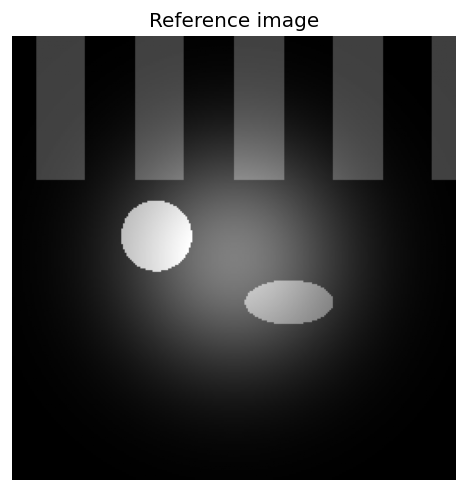

In [2]:
n = 256
y, x = np.mgrid[-1:1:complex(0, n), -1:1:complex(0, n)]
f = 0.3 * np.exp(-4 * (x**2 + y**2))
f += 0.35 * ((x + 0.35) ** 2 + (y - 0.1) ** 2 < 0.16**2)
f += 0.20 * ((x - 0.25) ** 2 / 0.2**2 + (y + 0.2) ** 2 / 0.1**2 < 1.0)
f += 0.15 * (np.sin(14 * x) > 0) * (y > 0.35)
f = np.clip(f, 0, 1)

fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.imshow(f, cmap="gray", origin="lower")
ax.set_title("Reference image")
ax.axis("off")
plt.show()


## Linear Fourier approximation

Linear approximation keeps all frequencies in a centered square:
$$
\widehat f_{\text{lin}}(\omega)=\widehat f(\omega)\,\mathbf{1}_{\|\omega\|_\infty\leq \Omega}.
$$


In [3]:
def linear_fourier_approx(img, m):
    n = img.shape[0]
    F = np.fft.fftshift(np.fft.fft2(img))
    mask = np.zeros_like(F, dtype=bool)
    c = n // 2
    m = int(np.clip(m, 1, n // 2 - 1))
    mask[c - m : c + m + 1, c - m : c + m + 1] = True
    Fr = np.where(mask, F, 0)
    out = np.fft.ifft2(np.fft.ifftshift(Fr)).real
    return np.clip(out, 0, 1)


## Nonlinear Haar approximation

Using an orthogonal Haar transform $\mathcal W$, we keep only the largest $K$ coefficients:
$$
w_K = w\cdot \mathbf 1_{|w|\ge \tau_K},\qquad f_K=\mathcal W^{-1}w_K.
$$


In [4]:
def haar_step_forward(v):
    a = (v[..., ::2] + v[..., 1::2]) / np.sqrt(2)
    d = (v[..., ::2] - v[..., 1::2]) / np.sqrt(2)
    return np.concatenate([a, d], axis=-1)

def haar_step_inverse(v):
    m = v.shape[-1] // 2
    a, d = v[..., :m], v[..., m:]
    out = np.empty(v.shape, dtype=v.dtype)
    out[..., ::2] = (a + d) / np.sqrt(2)
    out[..., 1::2] = (a - d) / np.sqrt(2)
    return out

def haar2_forward(img, level=4):
    out = img.copy().astype(float)
    n = img.shape[0]
    for j in range(level):
        m = n // (2**j)
        block = out[:m, :m]
        block = haar_step_forward(block)
        block = haar_step_forward(block.T).T
        out[:m, :m] = block
    return out

def haar2_inverse(coeff, level=4):
    out = coeff.copy().astype(float)
    n = coeff.shape[0]
    for j in reversed(range(level)):
        m = n // (2**j)
        block = out[:m, :m]
        block = haar_step_inverse(block.T).T
        block = haar_step_inverse(block)
        out[:m, :m] = block
    return out

def nonlinear_wavelet_approx(img, K, level=4):
    W = haar2_forward(img, level=level)
    K = int(np.clip(K, 1, W.size))
    thr = np.partition(np.abs(W).ravel(), -K)[-K]
    Wt = np.where(np.abs(W) >= thr, W, 0)
    rec = haar2_inverse(Wt, level=level)
    return np.clip(rec, 0, 1)


## Side-by-side comparison

At equal budget, compare MSE and visual structure retention.


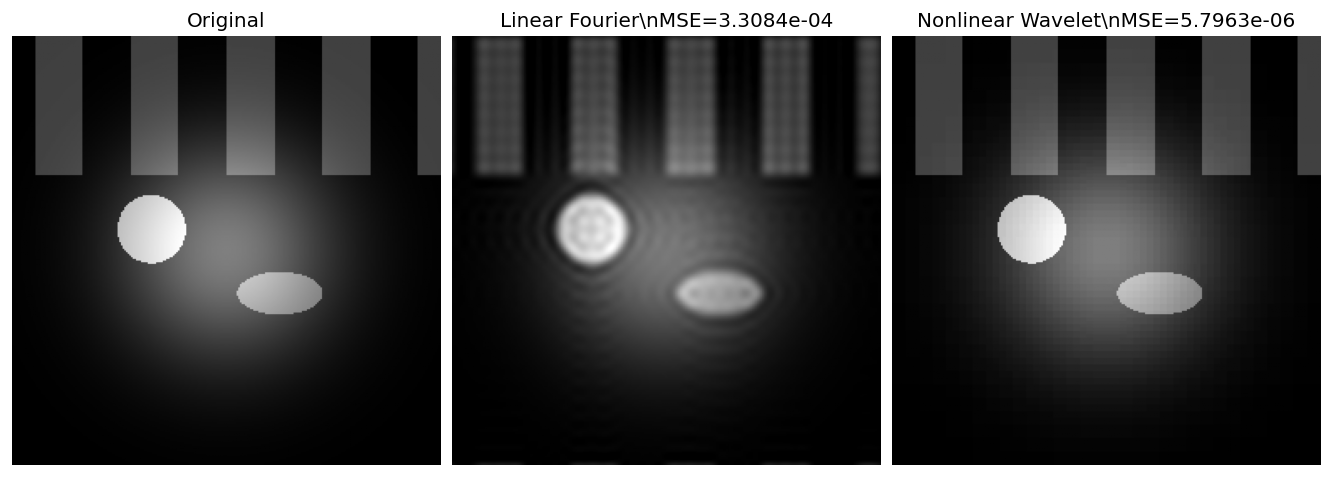

interactive(children=(IntSlider(value=24, description='budget', max=56, min=6, step=2), Output()), _dom_classe…

In [5]:
def compare_budget(b=24):
    n = f.shape[0]
    lin = linear_fourier_approx(f, b)
    K = (2 * b + 1) ** 2
    nlin = nonlinear_wavelet_approx(f, K=K)
    mse_lin = np.mean((lin - f) ** 2)
    mse_nlin = np.mean((nlin - f) ** 2)

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), constrained_layout=True)
    axes[0].imshow(f, cmap="gray", origin="lower")
    axes[0].set_title("Original")
    axes[1].imshow(lin, cmap="gray", origin="lower")
    axes[1].set_title(f"Linear Fourier\\nMSE={mse_lin:.4e}")
    axes[2].imshow(nlin, cmap="gray", origin="lower")
    axes[2].set_title(f"Nonlinear Wavelet\\nMSE={mse_nlin:.4e}")
    for ax in axes:
        ax.axis("off")
    plt.show()

# Static call for headless execution (keeps a representative budget comparison figure).
compare_budget(b=24);

from ipywidgets import interact, IntSlider
interact(compare_budget, b=IntSlider(min=6, max=56, step=2, value=24, description='budget'));


## Rate curves

We chart approximation error as function of retained coefficient budget.


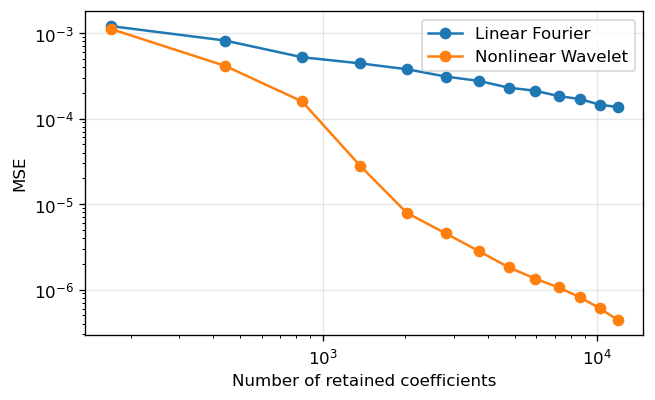

In [5]:
budgets = np.arange(6, 58, 4)
err_lin, err_nlin = [], []
for b in budgets:
    lin = linear_fourier_approx(f, b)
    K = (2 * b + 1) ** 2
    nlin = nonlinear_wavelet_approx(f, K=K)
    err_lin.append(np.mean((lin - f) ** 2))
    err_nlin.append(np.mean((nlin - f) ** 2))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot((2 * budgets + 1) ** 2, err_lin, "o-", label="Linear Fourier")
ax.plot((2 * budgets + 1) ** 2, err_nlin, "o-", label="Nonlinear Wavelet")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of retained coefficients")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## Bibliographical resources

- Stéphane Mallat, *A Wavelet Tour of Signal Processing*.
- David Donoho, *Compressed Sensing* (for sparsity intuition and nonlinear approximation culture).
- Ingrid Daubechies, *Ten Lectures on Wavelets*.
